In [1]:
!pip install mglearn
!pip install dabl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 5.4 MB/s eta 0:00:00


In [2]:
import warnings
import mglearn
warnings.filterwarnings('ignore')

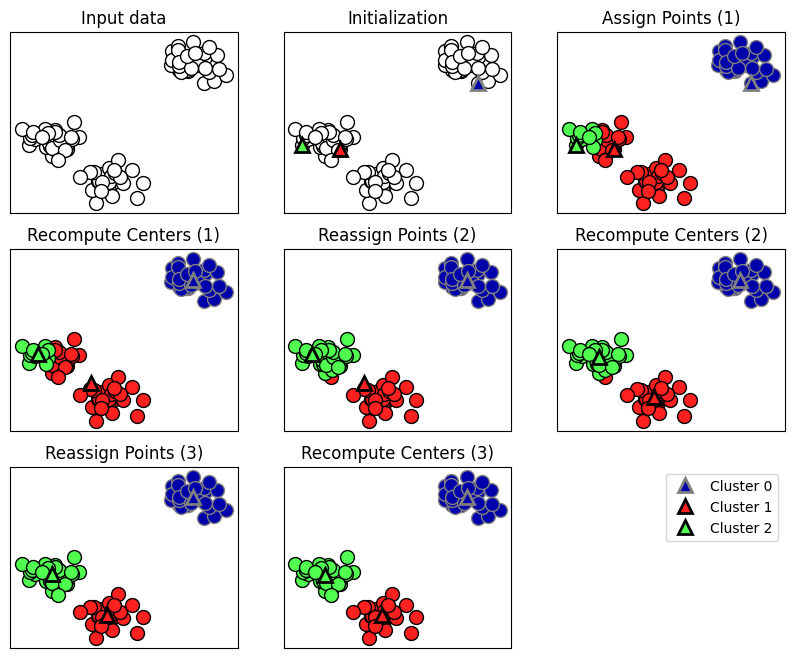

In [3]:
mglearn.plots.plot_kmeans_algorithm()

In [4]:
# for basic mathematics operation
import numpy as np

# for dataframe manipulations
import pandas as pd

# for Data Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

# for data analysis
import dabl

In [5]:
# importing the dataset
data = pd.read_csv('Mall_Customers.csv')

In [6]:
# lets check the shape of the dataset
print("Shape of the dataset :", data.shape)

Shape of the dataset : (200, 5)


In [7]:
# lets check the head of the data
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
# lets check the tail of the data
data.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [9]:
# lets check sample of the data
data.sample(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
128,129,Male,59,71,11
6,7,Female,35,18,6
63,64,Female,54,47,59


In [10]:
# describing the data
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
# describing the categorical data
data.describe(include = 'object')

,Gender
count,200
unique,2
top,Female
freq,112


In [12]:
# checking if there is any NULL data
data.isnull().any().any()

np.False_

In [13]:
# we want to perform clusters of Customers who share similar behaviour for that lets select the columns
# Spending score, and Annual Income

# Lets select the Spending score, and Annual Income Columns from the Data
x = data.loc[:, ['Spending Score (1-100)', 'Annual Income (k$)']].values

# let's check the shape of x
print(x.shape)

(200, 2)


In [14]:
# lets also check the data, which we are going to use for the clustering analysis
x_data  = pd.DataFrame(x)
x_data.head()
# where o->Spending Score, and 1->Annual Income

,0,1
0,39,15
1,81,15
2,6,16
3,77,16
4,40,17


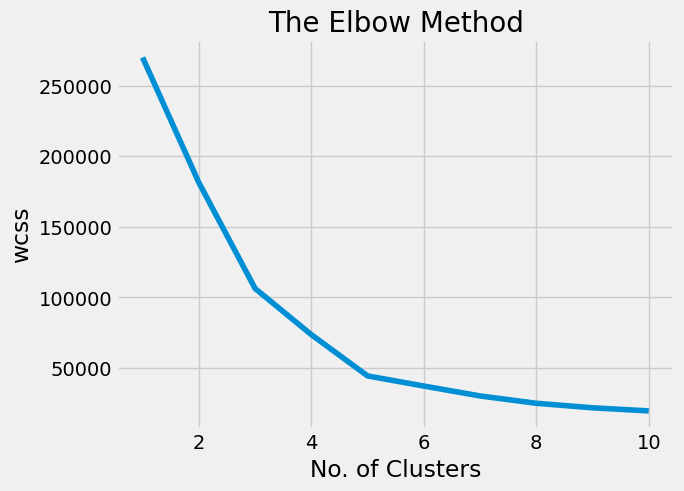

In [15]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')
plt.show()

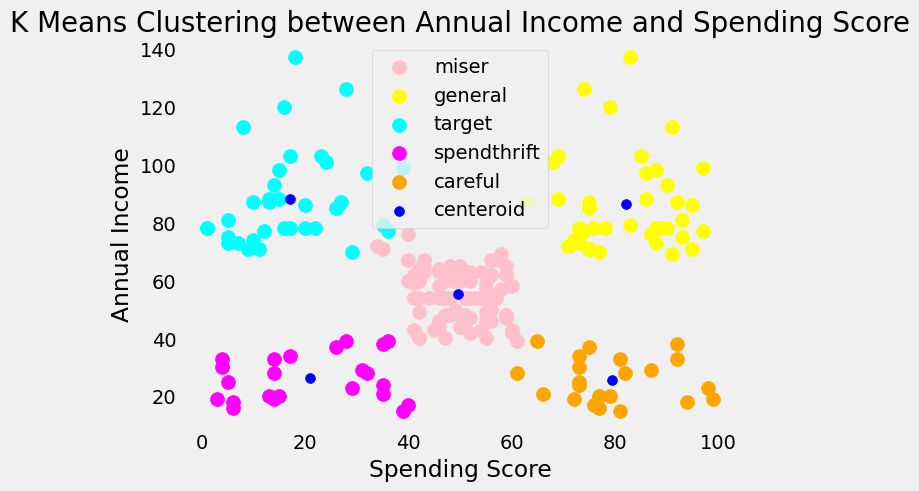

In [16]:
# lets visualize these clusters

plt.style.use('fivethirtyeight')

km = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_means = km.fit_predict(x)

plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s = 100, c = 'pink', label = 'miser')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s = 100, c = 'yellow', label = 'general')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s = 100, c = 'cyan', label = 'target')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s = 100, c = 'magenta', label = 'spendthrift')
plt.scatter(x[y_means == 4, 0], x[y_means == 4, 1], s = 100, c = 'orange', label = 'careful')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:, 1], s = 50, c = 'blue' , label = 'centeroid')


plt.style.use('fivethirtyeight')
plt.title('K Means Clustering between Annual Income and Spending Score', fontsize = 20)
plt.xlabel('Spending Score')
plt.ylabel('Annual Income')
plt.legend()
plt.grid()
plt.show()

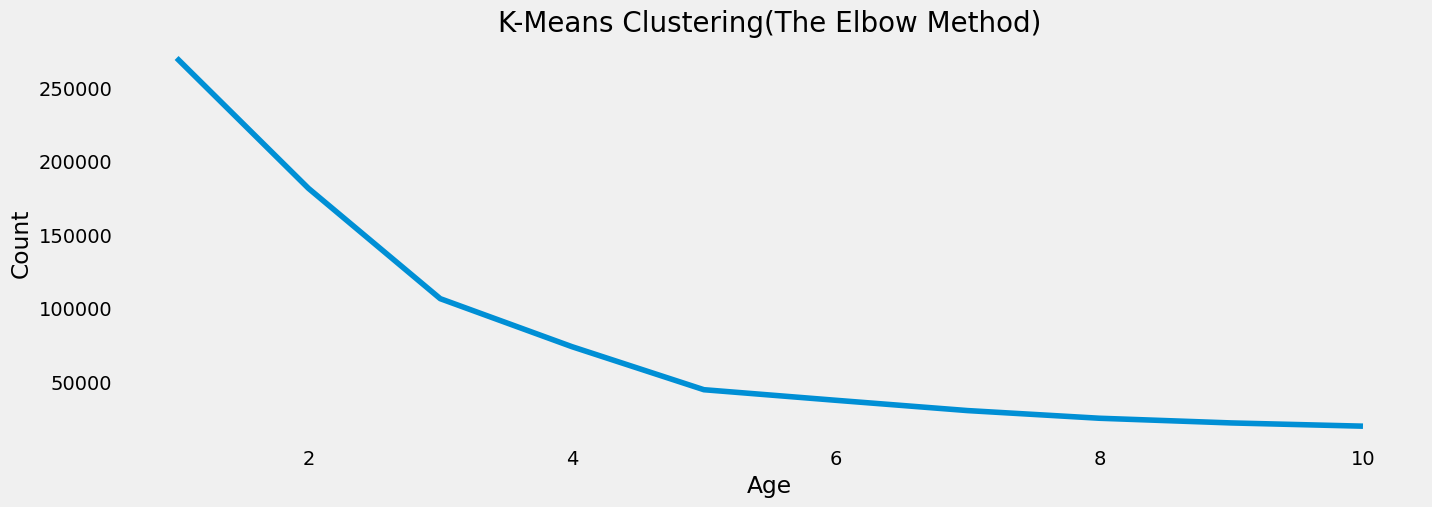

In [17]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

plt.rcParams['figure.figsize'] = (15, 5)
plt.plot(range(1, 11), wcss)
plt.title('K-Means Clustering(The Elbow Method)', fontsize = 20)
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid()
plt.show()

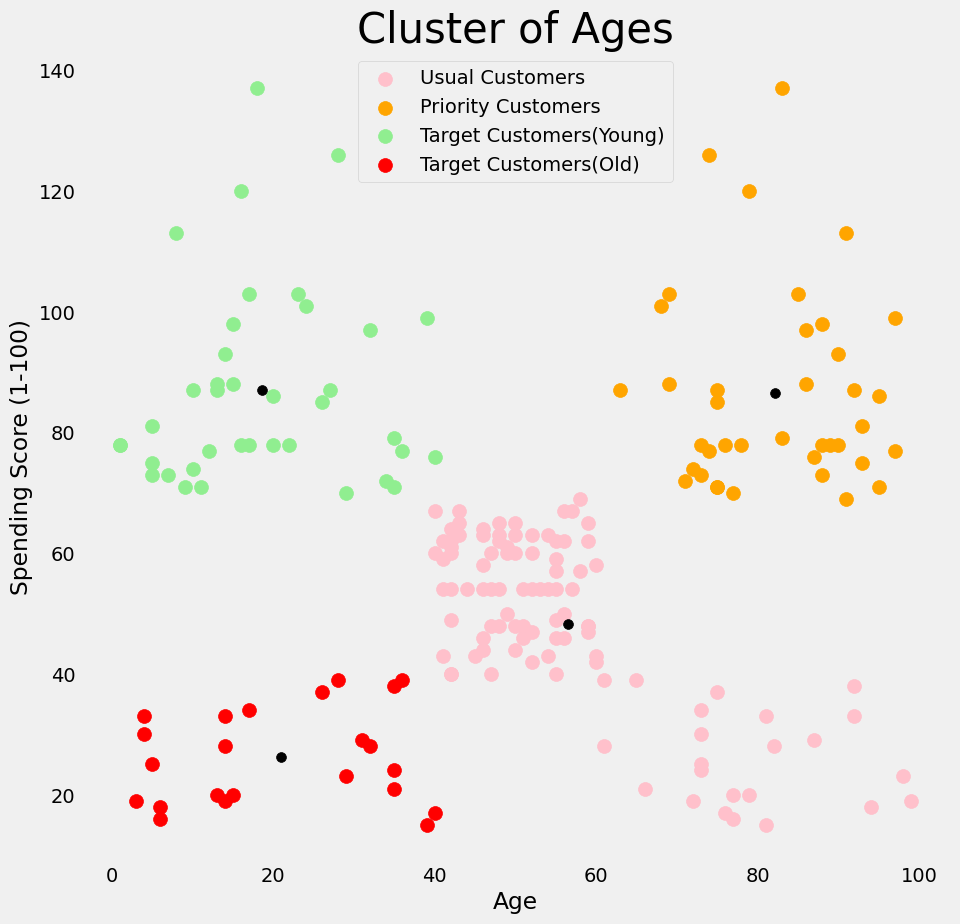

In [18]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
ymeans = kmeans.fit_predict(x)

plt.rcParams['figure.figsize'] = (10, 10)
plt.title('Cluster of Ages', fontsize = 30)

plt.scatter(x[ymeans == 0, 0], x[ymeans == 0, 1], s = 100, c = 'pink', label = 'Usual Customers' )
plt.scatter(x[ymeans == 1, 0], x[ymeans == 1, 1], s = 100, c = 'orange', label = 'Priority Customers')
plt.scatter(x[ymeans == 2, 0], x[ymeans == 2, 1], s = 100, c = 'lightgreen', label = 'Target Customers(Young)')
plt.scatter(x[ymeans == 3, 0], x[ymeans == 3, 1], s = 100, c = 'red', label = 'Target Customers(Old)')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 50, c = 'black')

plt.style.use('fivethirtyeight')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid()
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler

#Using Silhouette
df = pd.read_csv('Mall_Customers.csv')
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Store scores for the summary cell at the end
avg_scores = {}

print(f'Feature matrix shape: {X_scaled.shape}')

Feature matrix shape: (200, 2)


In [26]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

def plot_all_silhouettes(range_n_clusters, X, X_scaled, scaler):
    avg_scores = {}

    for n_clusters in range_n_clusters:
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # --- Silhouette Plot ---
        ax1.set_xlim([-0.2, 1])
        ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

        clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        cluster_labels = clusterer.fit_predict(X_scaled)

        silhouette_avg = silhouette_score(X_scaled, cluster_labels)
        avg_scores[n_clusters] = silhouette_avg

        print(f'n_clusters = {n_clusters} | avg silhouette score = {silhouette_avg:.4f}')

        sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            ith_vals = sample_silhouette_values[cluster_labels == i]
            ith_vals.sort()
            size_i = ith_vals.shape[0]
            y_upper = y_lower + size_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_vals,
                facecolor=color,
                edgecolor=color,
                alpha=0.7
            )

            ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
            y_lower = y_upper + 10

        ax1.set_title('Silhouette plot for each cluster')
        ax1.set_xlabel('Silhouette coefficient')
        ax1.set_ylabel('Cluster label')

        ax1.axvline(
            x=silhouette_avg,
            color='red',
            linestyle='--',
            label=f'Avg = {silhouette_avg:.3f}'
        )

        ax1.legend(loc='upper right')
        ax1.set_yticks([])
        ax1.set_xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # --- Scatter Plot ---
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)

        ax2.scatter(
            X[:, 0], X[:, 1],
            marker='.', s=60, lw=0,
            alpha=0.8, c=colors, edgecolor='k'
        )

        # Convert centers back to original scale
        centers_original = scaler.inverse_transform(clusterer.cluster_centers_)

        ax2.scatter(
            centers_original[:, 0], centers_original[:, 1],
            marker='o', c='white', alpha=1,
            s=250, edgecolor='k', zorder=5
        )

        for i, c in enumerate(centers_original):
            ax2.scatter(
                c[0], c[1],
                marker=f'${i}$',
                alpha=1, s=60,
                edgecolor='k', zorder=6
            )

        ax2.set_title('Clustered Data')
        ax2.set_xlabel('Feature 1')
        ax2.set_ylabel('Feature 2')

        plt.suptitle(
            f'Silhouette Analysis (n_clusters = {n_clusters})',
            fontsize=14, fontweight='bold'
        )

        plt.tight_layout()
        plt.show()

    return avg_scores

n_clusters = 2 | avg silhouette score = 0.3973


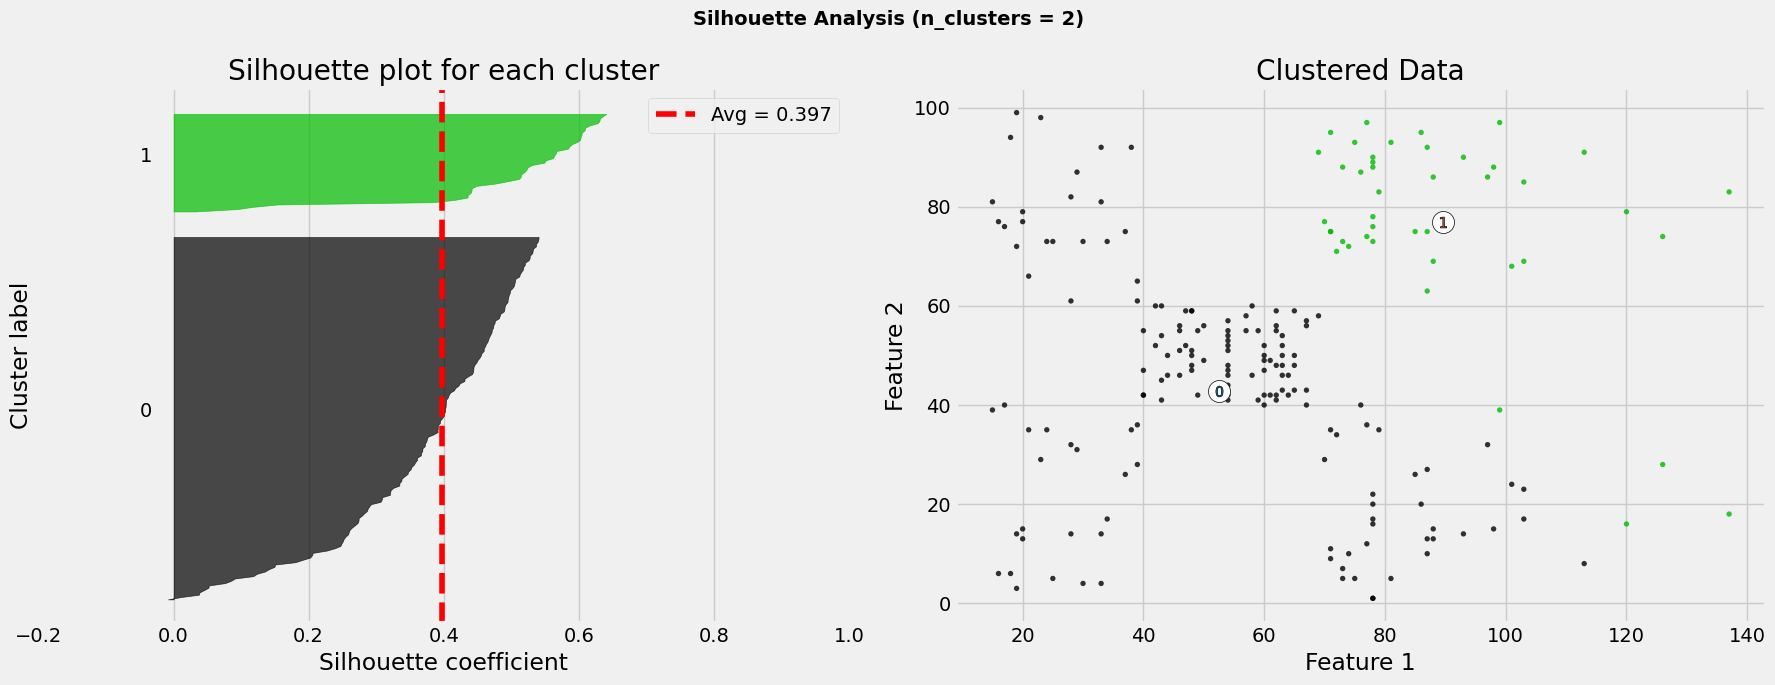

n_clusters = 3 | avg silhouette score = 0.4666


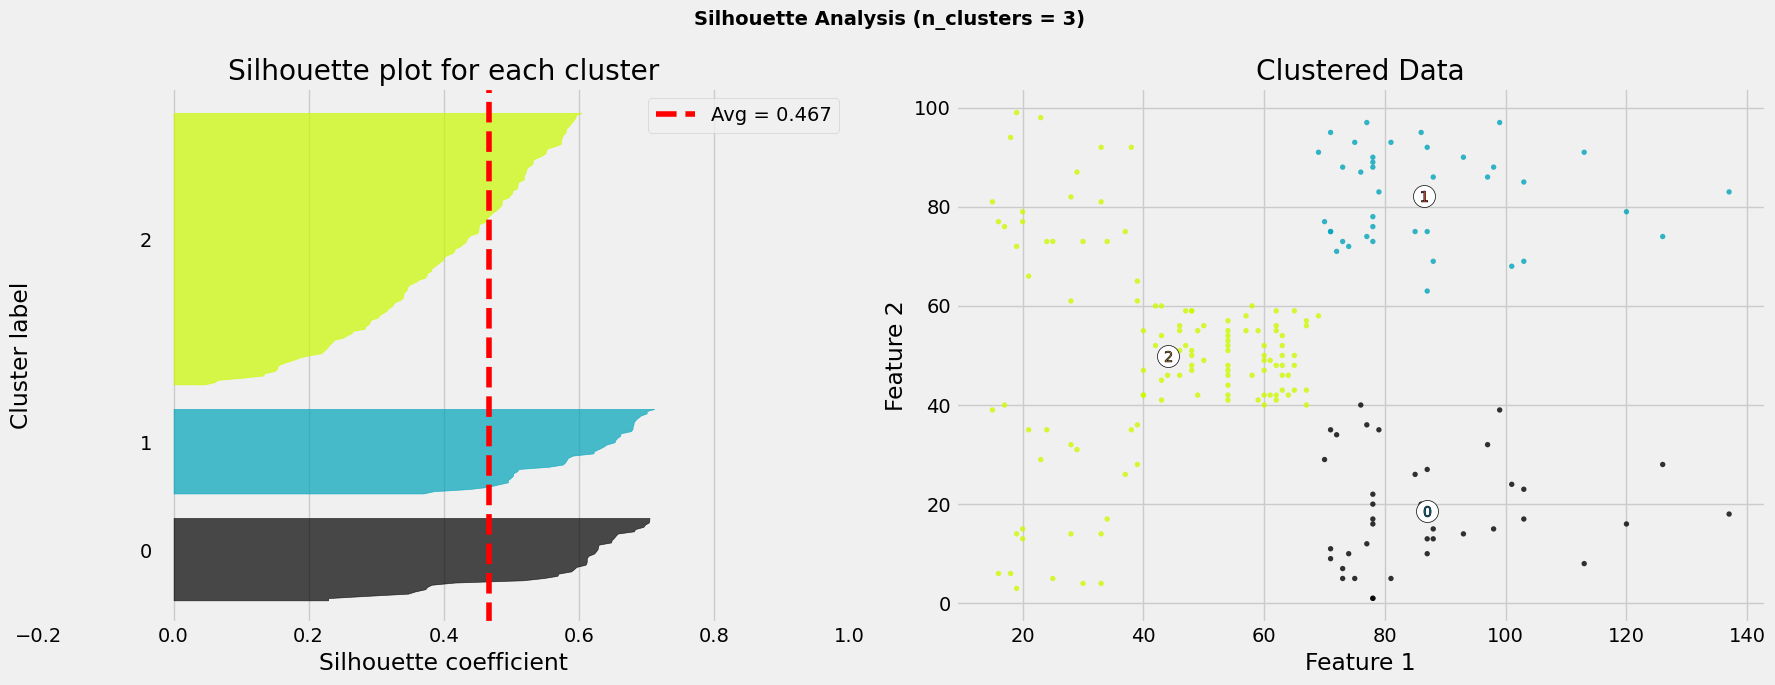

n_clusters = 4 | avg silhouette score = 0.4943


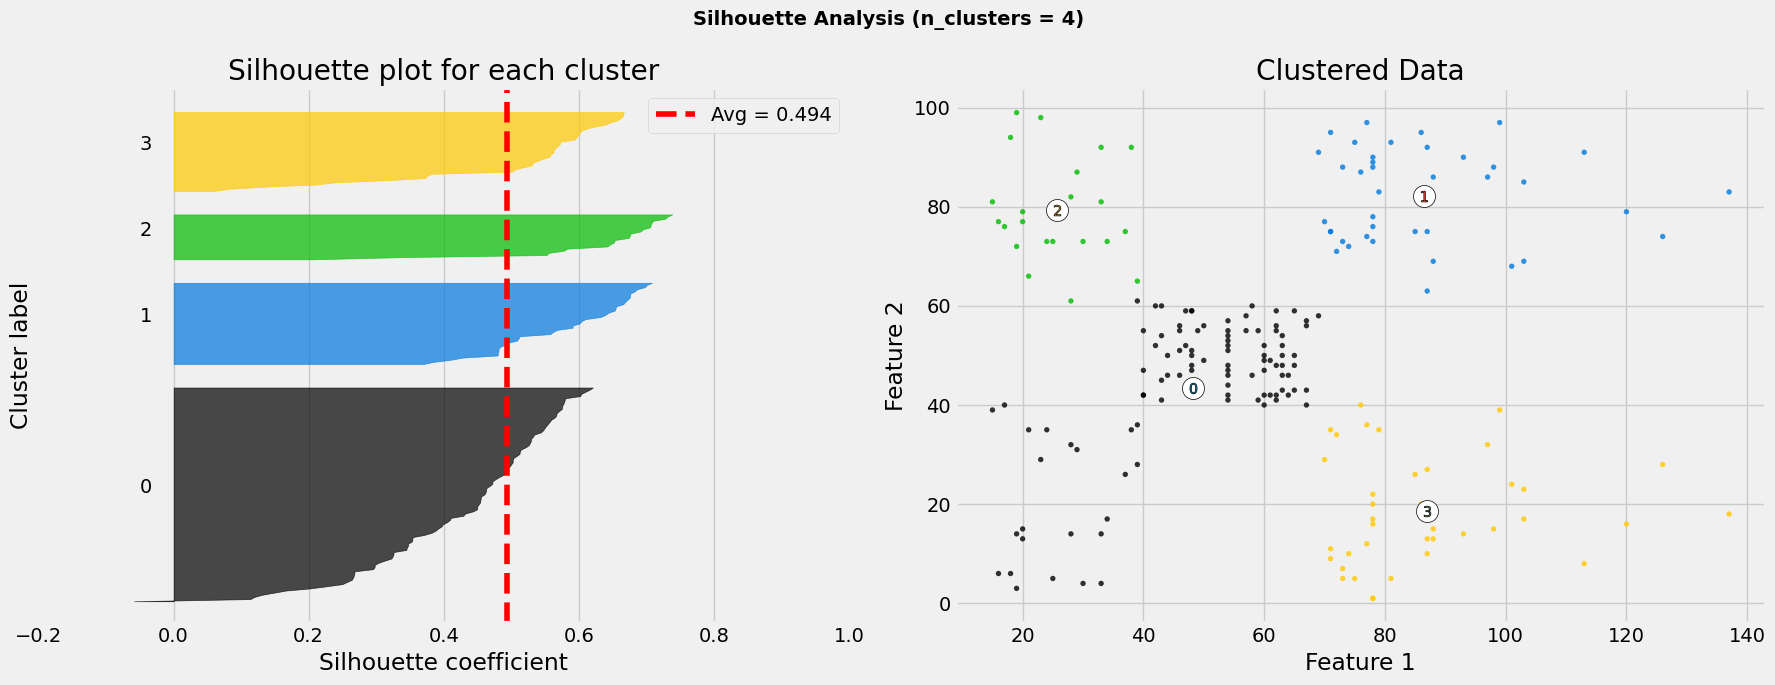

n_clusters = 5 | avg silhouette score = 0.5547


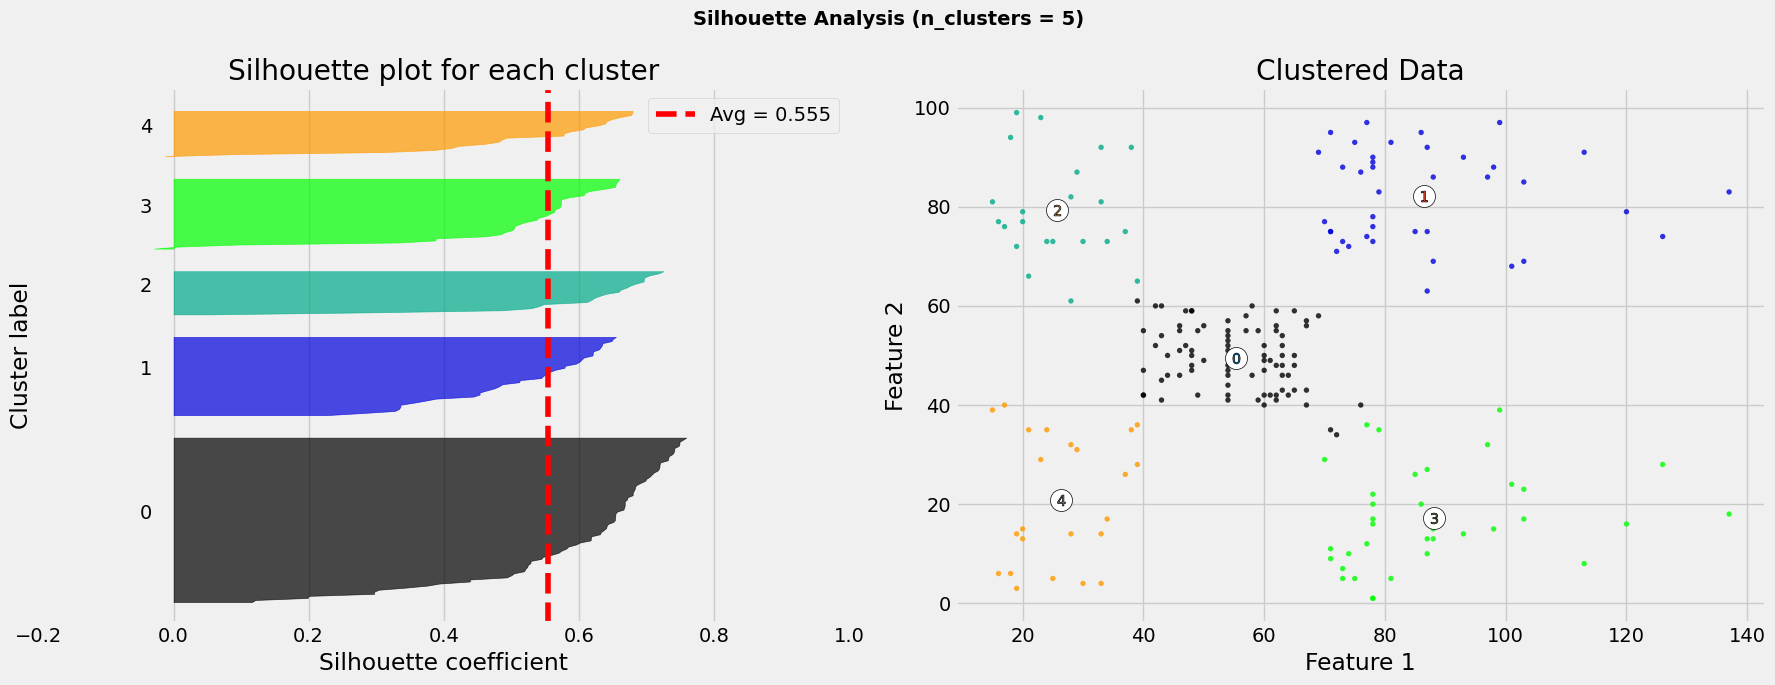

n_clusters = 6 | avg silhouette score = 0.5138


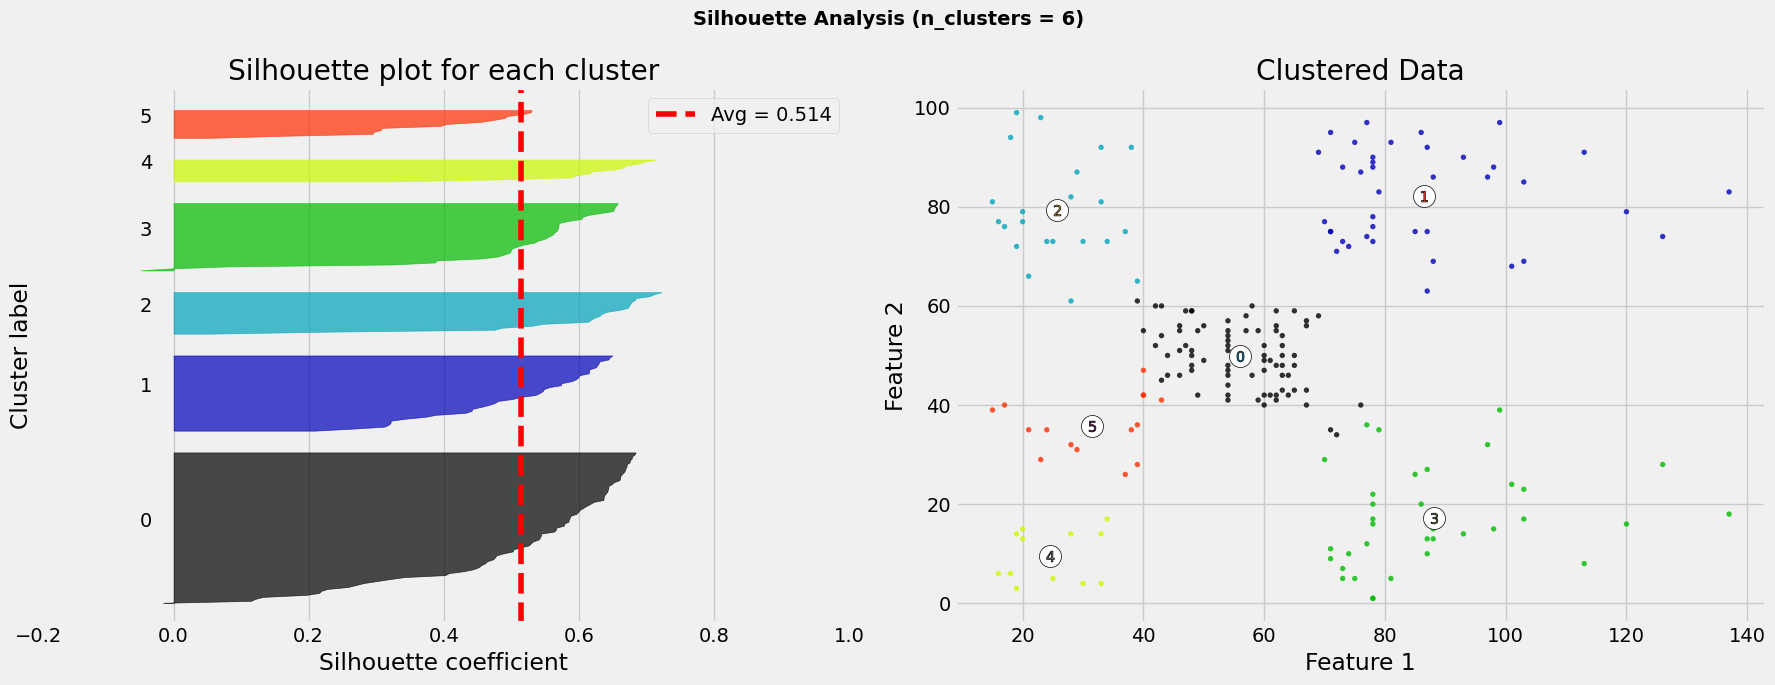

In [29]:
range_n_clusters = [2, 3, 4, 5, 6]

avg_scores = plot_all_silhouettes(range_n_clusters, X, X_scaled, scaler)
ks = list(avg_scores.keys())

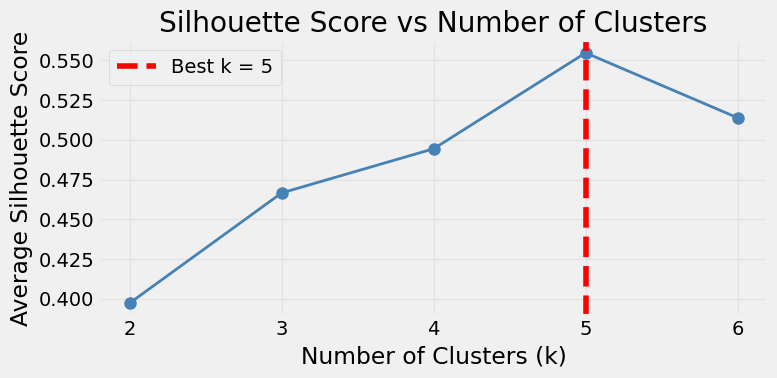


 Optimal number of clusters: k = 5  (score = 0.5547)


In [30]:
kc = sorted(avg_scores.keys())
scores = [avg_scores[k] for k in kc]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(kc, scores, 'o-', color='steelblue', linewidth=2, markersize=8)
best_k = ks[np.argmax(scores)]
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Average Silhouette Score')
ax.set_title('Silhouette Score vs Number of Clusters')
ax.set_xticks(ks)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n Optimal number of clusters: k = {best_k}  (score = {max(scores):.4f})')
